-*- encoding: utf-8 -*-
This file is part of GaPSE
Copyright (C) 2022 Matteo Foglieni
GaPSE is free software: you can redistribute it and/or modify
it under the terms of the GNU General Public License as published by
the Free Software Foundation, either version 3 of the License, or
(at your option) any later version.
GaPSE is distributed in the hope that it will be useful, but
WITHOUT ANY WARRANTY; without even the implied warranty of
MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE. See the GNU
General Public License for more details.
You should have received a copy of the GNU General Public License
along with GaPSE. If not, see <http://www.gnu.org/licenses/>.

## GaPSE setup

In [1]:
using Pkg
Pkg.activate(@__DIR__)

# This environment is (re)built here, so that a fresh clone - or a different
# Julia version - needs no manual setup step.
#  - GaPSE is NOT a registered package: an environment reaches it only through
#    the `path` entry that `Pkg.develop` writes into `Manifest.toml`. Checking
#    `Base.identify_package` alone is not enough: it resolves the UUID from
#    `Project.toml` and succeeds even when the source cannot be found.
#  - `Project.toml` holds names and UUIDs only, is Julia-version INdependent and
#    is tracked by git; it is rebuilt from `THEORY_DEPS` if it is missing.
#  - `Manifest.toml` holds the resolved versions, IS Julia-version specific and
#    is gitignored; `Pkg.resolve()` + `Pkg.instantiate()` rebuild it for the
#    Julia that is running. `resolve` first, or `instantiate` refuses whenever
#    `Project.toml` declares more than the manifest knows about.
# Nothing is downloaded when the environment is already complete.
let THEORY_DEPS = ["Plots", "PyPlot", "LaTeXStrings", "QuadGK",
                   "DelimitedFiles", "Printf", "SpecialFunctions"]
    declared = collect(keys(Pkg.project().dependencies))
    id = Base.identify_package("GaPSE")
    if !("GaPSE" in declared) || isnothing(id) || isnothing(Base.locate_package(id))
        @info "theory/: making the GaPSE of this repository available"
        Pkg.develop(path=dirname(@__DIR__))
    end
    todo = filter(d -> !(d in declared), THEORY_DEPS)
    isempty(todo) || (@info "theory/: adding the missing dependencies" todo; Pkg.add(todo))
    Pkg.resolve()
    Pkg.instantiate()
end

using GaPSE

using Plots, LaTeXStrings, Printf
using SpecialFunctions: sphericalbesselj

# `pyplot()` needs a working matplotlib; `gr()` is used instead where it is absent
#try
#    pyplot()
#catch err
#    @warn "theory/: PyPlot cannot be initialised; falling back to the GR backend. " *
#          "The figures will look slightly different." exception = err
#    gr()
#end
gr()

  Activating project at `~/AAA_TESI_MAGISTRALE/GaPSE_CODING/GaPSE-worktree/myspline/theory`
     Project No packages added to or removed from `~/AAA_TESI_MAGISTRALE/GaPSE_CODING/GaPSE-worktree/myspline/theory/Project.toml`
    Manifest No packages added to or removed from `~/AAA_TESI_MAGISTRALE/GaPSE_CODING/GaPSE-worktree/myspline/theory/Manifest.toml`


Plots.GRBackend()

In [2]:
const PATH_TO_GAPSE = normpath(joinpath(@__DIR__, ".."))

# Directory where the plots and the data will be saved
const DIR = joinpath(@__DIR__, "spherical_bessels")
@assert isdir(DIR) "ERROR: DIR=$DIR DOESN'T EXIST!!!"

# Set this to `true` in order to save a copy of the plots where the
# documentation expects to find them.
const SAVE_TO_DOCS = true
const DOCS_ASSETS = joinpath(PATH_TO_GAPSE, "docs", "src", "assets", "misc")

"/Users/di75tom/AAA_TESI_MAGISTRALE/GaPSE_CODING/GaPSE-worktree/myspline/docs/src/assets/misc"

## kwargs, L_MAX, logticks, etc

In [3]:
# the orders we show in the first figure, with the style used for each of them
const ORDERS = [
    (0, :red, :solid),
    (1, :blue, :solid),
    (2, :green, :dash),
    (3, :brown, :dash),
    (4, :black, :dot),
]

# the largest order for which we compute the first zero
const L_MAX = 100

100

In [4]:
"""
    plot_kwargs(kwargs...) :: Dict

The defaults every figure of this directory shares, with anything in `kwargs...`
overriding them. `merge` keeps the value of the **last** dictionary for a repeated
key, so whatever is passed in always wins:

```julia
plot_kwargs()                       # the defaults
plot_kwargs(:dpi => 150)            # the defaults, with dpi = 150
plot_kwargs(:whatever => 3)         # unknown keys are passed through to Plots
```
"""
function plot_kwargs(kwargs...)
    dict_defaults = Dict(
        :size => (1000, 400), :dpi => 300, :legendposition => :outerright,
        :legendfontsize => 11, :guidefontsize => 14, :tickfontsize => 11,
        :titlefontsize => 16, :left_margin => 10Plots.mm, :bottom_margin => 6Plots.mm,
        # a y label that reads horizontally: see `hlabel` for the padding it needs
        :yguidefontrotation => -90,
    )
    # in `merge`, if a key is repeated the LAST collection has priority
    merge(dict_defaults, Dict(kwargs))
end

plot_kwargs

In [5]:
"""
    logticks(lo, hi; step=1) :: Vector{Float64}
    logticks(xs; step=1) :: Vector{Float64}

Decade ticks covering `[lo, hi]`, one every `step` decades. The second form reads the
range off the extrema of `xs`, which is handy when the ticks should simply follow the
data:

```julia
logticks(1e-7, 1e4; step=2)     # 1e-7, 1e-5, ..., 1e3
logticks(qs)                    # one tick per decade spanned by qs
```
"""
logticks(lo, hi; step=1) = 10.0 .^ (floor(Int, log10(lo)):step:ceil(Int, log10(hi)))
logticks(xs; step=1) = logticks(extrema(xs)...; step=step)

logticks (generic function with 2 methods)

In [6]:
"""
    hlabel(s; pad=10) :: String

A y-axis label meant to be read horizontally, i.e. together with
`yguidefontrotation = -90` (which `plot_kwargs` sets by default).

`Plots` places the y guide at a fixed offset from the axis, measured as if the label
were vertical. Once it is rotated flat it therefore lands on top of the tick labels,
and there is no portable option to move it: padding it with trailing spaces is the
only thing that works across backends. Keeping that workaround inside one function means
only `pad` has to be tuned per figure, and a better mechanism - should `Plots` ever
grow one - has to be applied in a single place.
"""
hlabel(s; pad=10) = s * " "^pad

hlabel

In [7]:
"""
    vspec(r, l; ls=:dash, lw=2, c=:black, alpha=0.55, fmt=:sci1) :: NamedTuple

One entry for `vlines!`: a pair of vertical lines at `r = (lo, hi)`, labelled `l`,
drawn with the given style. `fmt` is `:sci1` for `1.0e-06` or `:sci0` for `1e-06`.
Passing `r = nothing` makes `vlines!` skip it, which is how a figure drops one of the
markers without having to rebuild the whole list.
"""
vspec(r, l; ls=:dash, lw=2, c=:black, alpha=0.55, fmt=:sci1) =
    (r=r, l=l, ls=ls, lw=lw, c=c, alpha=alpha, fmt=fmt)

vspec

In [8]:
"""
    vlines!(p, specs) :: Plots.Plot

Draw every `vspec` of `specs` on `p`.

This takes the place of the earlier `r1/l1/ls1/lw1/c1/alpha1`, `r2/...`, `r3/...`
keyword triplets: eighteen keywords that only ever described three lines, could not
describe a fourth, and had to be forwarded by hand through every plotting function.
A figure now carries a single `specs` keyword, overriding one entry is
`vspec(KS_DATA, "input file"; c=:green)`, and adding a fourth marker is one more
element of the vector.
"""
function vlines!(p, specs)
    for v in specs
        isnothing(v.r) && continue
        lab = v.fmt === :sci0 ? @sprintf("%s: [%.0e, %.0e]", v.l, v.r...) :
              @sprintf("%s: [%.1e, %.1e]", v.l, v.r...)
        vline!(p, [v.r...]; ls=v.ls, lw=v.lw, c=v.c, alpha=v.alpha, label=lab)
    end
    p
end

vlines!

## The double factorial and the first zeros

In [9]:
"""
    dfact(n) ::Int

Return the double factorial ``n!!`` (with ``n!! = 1`` for ``n \\leq 0``).
"""
dfact(n) = n <= 0 ? 1 : prod(n:-2:1)

dfact

In [10]:
"""
    small_x(x, l) ::Float64

Return the leading term of the series expansion of ``j_\\ell`` near the origin:

```math
j_\\ell(x) = \\frac{x^\\ell}{(2\\ell+1)!!} \\left(1 + \\mathcal{O}(x^2)\\right)
    = x^\\ell \\left(
        \\frac{\\sqrt{\\pi}}{2^{\\ell+1} \\, \\Gamma(\\ell+3/2)} + \\mathcal{O}(x^2)
    \\right) \\; .
```

The two forms coincide because
``\\Gamma(\\ell+3/2) = \\sqrt{\\pi} \\, (2\\ell+1)!! \\, / \\, 2^{\\ell+1}``.
"""
small_x(x, l) = x^l / dfact(2 * l + 1)

small_x

In [11]:
"""
    first_zero(l; x_max_pad=30.0, N=200_000, rtol=1e-12) ::Float64

Return the first zero of ``j_\\ell(x)`` for ``x > 0``, found by scanning
``[\\ell + 0.1, \\ell + x_\\mathrm{max\\_pad}]`` for a sign change and then bisecting it.

There is no need for anything fancier: ``j_\\ell`` has no zero below ``\\ell`` (it is
still in its ``x^\\ell`` growth there), and its first zero sits around
``\\ell + 1.86 \\, \\ell^{1/3}``, so the scanned window always contains it.
"""
function first_zero(l; x_max_pad=30.0, N=200_000, rtol=1e-12)
    lo, hi = max(1e-6, float(l) + 0.1), float(l) + x_max_pad
    xs = range(lo, hi, length=N)
    vs = [sphericalbesselj(l, x) for x in xs]

    i = findfirst(k -> sign(vs[k]) != sign(vs[k+1]), 1:N-1)
    @assert !isnothing(i) "ERROR: no sign change of j_$l in [$lo, $hi] !!!"

    a, b = xs[i], xs[i+1]
    fa = sphericalbesselj(l, a)
    while (b - a) > rtol * b
        m = (a + b) / 2
        fm = sphericalbesselj(l, m)
        if sign(fm) == sign(fa)
            a, fa = m, fm
        else
            b = m
        end
    end
    return (a + b) / 2
end

first_zero

In [12]:
"""
    linear_fit(xs, ys) ::Tuple{Float64,Float64}

Return the `(q, m)` of the least-squares straight line ``y = q + m \\, x``.
"""
function linear_fit(xs, ys)
    n = length(xs)
    mx, my = sum(xs) / n, sum(ys) / n
    m = sum((xs .- mx) .* (ys .- my)) / sum((xs .- mx) .^ 2)
    return my - m * mx, m
end

linear_fit

## Plot functions

In [13]:
"""
    plot_bessels(; ls, xs, xlabel, ylabel, title, lw, kwargs...) :: Plots.Plot

The spherical Bessel functions ``j_\\ell(x)`` themselves, on linear axes.
`ls` is the list of `(order, colour, linestyle)` triplets to draw.
"""
function plot_bessels(;
    ls=ORDERS, xs=range(0, 20, length=2000),
    xlabel=L"\mathrm{adimensional \; argument} \; x",
    ylabel=hlabel(L"j_{\ell}(x)"; pad=2),
    title="The spherical Bessel functions "*L"j_\ell(x)",
    lw=4, left_margin=14Plots.mm,
    kwargs...
)
    p = plot(; xlabel=xlabel, ylabel=ylabel, title=title,
        plot_kwargs(:left_margin => left_margin, kwargs...)...)
    for (l, col, sty) in ls
        plot!(p, xs, [sphericalbesselj(l, x) for x in xs];
            label=L"\ell = %$l", color=col, ls=sty, lw=lw)
    end
    p
end

plot_bessels

In [14]:
"""
    plot_small_x(; ls, xs, ..., xticks*/yticks*, kwargs...) :: Plots.Plot

``|j_\\ell(x)|`` against its leading small-``x`` term ``x^\\ell/(2\\ell+1)!!``, log-log.
Where the two coincide is the region in which the expansion may be used.
"""
function plot_small_x(;
    ls=ORDERS, xs=10 .^ range(-3, 1.3, length=1000),
    xscale=:log10, yscale=:log10,
    xlabel="adimensional argument "*L"x", 
    ylabel=hlabel(L"|j_{\ell}(x)|"; pad=5),
    title="Where the small-" * L"x" * " expansion holds",
    ylims=(0.8e-15, 1.2e3), lw=4, lw_asym=2, left_margin=16Plots.mm,
    xticksmin=1e-3, xticksmax=1e2, xticksstep=1,
    yticksmin=1e-15, yticksmax=1e3, yticksstep=3,
    kwargs...
)
    p = plot(; xscale=xscale, yscale=yscale, xlabel=xlabel, ylabel=ylabel,
        title=title, ylims=ylims,
        plot_kwargs(:left_margin => left_margin, kwargs...)...)
    for (l, col, _) in ls
        plot!(p, xs, abs.([sphericalbesselj(l, x) for x in xs]);
            label=L"j_{%$l}(x)", color=col, ls=:solid, lw=lw)
        plot!(p, xs, [small_x(x, l) for x in xs];
            label=L"x^{%$l} / %$(dfact(2 * l + 1))", color=col, ls=:dash, lw=lw_asym)
    end
    xticks!(p, logticks(xticksmin, xticksmax; step=xticksstep))
    yticks!(p, logticks(yticksmin, yticksmax; step=yticksstep))
    p
end

plot_small_x

In [15]:
"""
    plot_first_zeros(zeros_l; ls, ..., kwargs...) :: Plots.Plot

The first zero of ``j_\\ell`` against ``\\ell``, with the linear fit and the
asymptotic ``\\ell + 1.8557\\,\\ell^{1/3}``.

The points are drawn with `plot!(lw=0, markershape=...)` and not with `scatter!`:
with the PyPlot backend the latter routes to `plt.scatter`, which warns
"No data for colormapping provided via 'c'" when the colour is a single value.
"""
function plot_first_zeros(zeros_l;
    ls=0:L_MAX,
    xlabel="spherical bessel order "*L"\ell", 
    ylabel=hlabel(L"x_0(j_{\ell})"; pad=4),
    title="First zero of " * L"j_{\ell}",
    lw=4, ms=4, left_margin=14Plots.mm,
    show_fit=true, show_asymptote=true,
    kwargs...
)
    q, m = linear_fit(collect(ls), zeros_l)
    p = plot(; xlabel=xlabel, ylabel=ylabel, title=title,
        plot_kwargs(:left_margin => left_margin, kwargs...)...)
    plot!(p, ls, zeros_l; lw=0, markershape=:circle, ms=ms, mc=:black, msw=0,
        label=L"\mathrm{numerical}")
    show_fit && plot!(p, ls, [q + m * l for l in ls];
        label=L"%$(round(q, digits=2)) + %$(round(m, digits=2)) \, \ell",
        color=:red, ls=:dash, lw=lw)
    show_asymptote && plot!(p, ls, [l + 1.8557 * l^(1 / 3) for l in ls];
        label=L"\ell + 1.8557 \, \ell^{1/3}", color=:blue, ls=:dot, lw=lw)
    p
end

plot_first_zeros

In [16]:
"""
    plot_small_x_ratio(; ls, xs, ..., legendpad, kwargs...) :: Plots.Plot

The ratio ``|j_\\ell(x)| \\, (2\\ell+1)!! \\, / \\, x^\\ell`` between the two families of
curves drawn by `plot_small_x`, i.e. how far the leading term of the series is from the
function itself. It is meant as the lower panel of `plot_small_x_with_ratio`: on the
log-log plot above the two curves of each ``\\ell`` look superimposed over several
decades, and `ylims = (0.9, 1.1)` turns that impression into a number. The expansion is
good to 10% wherever the ratio stays inside the box, which it leaves at ``x = 0.79``
for ``\\ell = 0`` and at ``1.02``, ``1.21``, ``1.37``, ``1.52`` for
``\\ell = 1 \\ldots 4``: ``x \\simeq 1`` for every practical purpose.

`legendpad` is the number of blanks appended to every label. A `:outerright` legend is
as wide as its longest entry and that width is taken away from the plot area, so two
stacked panels share the same x axis only if their legends are equally wide; the labels
here are shorter than those of `plot_small_x`, hence the padding. It is the same
reasoning as `hlabel` applies to the y guide, and like `pad` there it is a per-figure
number because it depends on the backend's font metrics.
"""
function plot_small_x_ratio(;
    ls=ORDERS, xs=10 .^ range(-3, 1.3, length=1000),
    xscale=:log10,
    xlabel="adimensional argument " * L"x",
    ylabel=hlabel(L"\mathrm{ratio}"; pad=5),
    title="", ylims=(0.9, 1.1), yticks=0.9:0.05:1.1,
    lw=4, left_margin=16Plots.mm, legendpad=5,
    xticksmin=1e-3, xticksmax=1e2, xticksstep=1,
    kwargs...
)
    p = plot(; xscale=xscale, xlabel=xlabel, ylabel=ylabel, title=title,
        ylims=ylims, yticks=yticks,
        plot_kwargs(:left_margin => left_margin, kwargs...)...)
    hline!(p, [1.0]; c=:black, ls=:dash, lw=2, alpha=0.55, label="")
    for (l, col, _) in ls
        plot!(p, xs, [abs(sphericalbesselj(l, x)) / small_x(x, l) for x in xs];
            label=L"\ell = %$l" * " "^legendpad, color=col, ls=:solid, lw=lw)
    end
    xticks!(p, logticks(xticksmin, xticksmax; step=xticksstep))
    p
end

plot_small_x_ratio

In [17]:
"""
    plot_small_x_with_ratio(; heights, size, top, bottom, kwargs...) :: Plots.Plot

`plot_small_x` with `plot_small_x_ratio` stacked underneath it, the lower panel being
the shorter of the two. `heights` are the fractions of the figure the two panels take,
`top` and `bottom` are NamedTuples forwarded to the respective functions, so either
panel can be tweaked without touching the other:

```julia
plot_small_x_with_ratio()                             # the defaults
plot_small_x_with_ratio(heights=(0.8, 0.2))           # a thinner ratio panel
plot_small_x_with_ratio(bottom=(ylims=(0.99, 1.01),)) # a closer look at the ratio
```

The x guide is dropped from the upper panel, since the two panels share the axis.
"""
function plot_small_x_with_ratio(;
    heights=(0.72, 0.28), size=(1000, 560), top=(;), bottom=(;), kwargs...
)
    p_top = plot_small_x(; xlabel="", bottom_margin=0Plots.mm, top...)
    p_bot = plot_small_x_ratio(; bottom...)
    plot(p_top, p_bot; layout=grid(2, 1, heights=[heights...]),
        size=size, link=:x, kwargs...)
end

plot_small_x_with_ratio

In [18]:
"""
    plot_first_zeros_ratio(zeros_l; ..., legendpad, kwargs...) :: Plots.Plot

The two approximations drawn by `plot_first_zeros` divided by the numerical first zero.
It is meant as the lower panel of `plot_first_zeros_with_ratio`: on the linear plot
above all three curves lie on top of each other, and `ylims = (0.9, 1.1)` shows what
that hides. Neither approximation is inside the box at small ``\\ell``: the straight
line overshoots by 51% at ``\\ell = 0`` and enters only at ``\\ell = 4``, while the
asymptotic form vanishes at ``\\ell = 0`` and enters from below at ``\\ell = 7``. From
there on they part company: the fit is within 1% from ``\\ell = 12``, the asymptotic
form only from ``\\ell = 69``, which is the sense in which the latter is the one that is
*asymptotically* right.

See `plot_small_x_ratio` for what `legendpad` is for; here the two labels are the same
as in the upper panel, so no padding is needed.
"""
function plot_first_zeros_ratio(zeros_l;
    ls=0:L_MAX,
    xlabel="spherical bessel order " * L"\ell",
    ylabel=hlabel(L"\mathrm{ratio}"; pad=4),
    title="", ylims=(0.9, 1.1), yticks=0.9:0.05:1.1,
    lw=4, left_margin=14Plots.mm, legendpad=0,
    show_fit=true, show_asymptote=true,
    kwargs...
)
    q, m = linear_fit(collect(ls), zeros_l)
    p = plot(; xlabel=xlabel, ylabel=ylabel, title=title, ylims=ylims, yticks=yticks,
        plot_kwargs(:left_margin => left_margin, kwargs...)...)
    hline!(p, [1.0]; c=:black, ls=:dash, lw=2, alpha=0.55, label="")
    show_fit && plot!(p, ls, [(q + m * l) / z for (l, z) in zip(ls, zeros_l)];
        label=L"%$(round(q, digits=2)) + %$(round(m, digits=2)) \, \ell" * " "^legendpad,
        color=:red, ls=:dash, lw=lw)
    show_asymptote && plot!(p, ls, [(l + 1.8557 * l^(1 / 3)) / z for (l, z) in zip(ls, zeros_l)];
        label=L"\ell + 1.8557 \, \ell^{1/3}" * " "^legendpad,
        color=:blue, ls=:dot, lw=lw)
    p
end

plot_first_zeros_ratio

In [19]:
"""
    plot_first_zeros_with_ratio(zeros_l; heights, size, top, bottom, kwargs...) :: Plots.Plot

`plot_first_zeros` with `plot_first_zeros_ratio` stacked underneath it; same
conventions as `plot_small_x_with_ratio`.
"""
function plot_first_zeros_with_ratio(zeros_l;
    heights=(0.72, 0.28), size=(1000, 560), top=(;), bottom=(;), kwargs...
)
    p_top = plot_first_zeros(zeros_l; xlabel="", bottom_margin=0Plots.mm, top...)
    p_bot = plot_first_zeros_ratio(zeros_l; bottom...)
    plot(p_top, p_bot; layout=grid(2, 1, heights=[heights...]),
        size=size, link=:x, kwargs...)
end

plot_first_zeros_with_ratio

## Save functions

In [20]:
"""
    save_plot(p, name) :: Nothing

Write `p` into `spherical_bessels/`, and into the documentation assets when
`SAVE_TO_DOCS` is set. Plotting and saving are kept apart so that a figure can be
looked at, tweaked and only then written out.
"""
function save_plot(p, name)
    savefig(p, joinpath(DIR, name))
    SAVE_TO_DOCS && isdir(DOCS_ASSETS) && savefig(p, joinpath(DOCS_ASSETS, name))
    nothing
end

save_plot

In [21]:
"""
    save_data(zeros_l)

Save in `spherical_bessels/first_zeros.txt` the first zero of ``j_\\ell`` for
``\\ell = 0, ..., L_\\mathrm{MAX}``, together with the two approximations plotted by
`plot_first_zeros`.
"""
function save_data(zeros_l)
    ls = 0:L_MAX
    q, m = linear_fit(collect(ls), zeros_l)

    out = joinpath(DIR, "first_zeros.txt")
    isfile(out) && rm(out)
    open(out, "w") do io
        println(io, GaPSE.BRAND)
        println(io, "#\n# The first zero of the spherical Bessel function j_l(x), for x > 0 .")
        println(io, "#")
        println(io, "# Least-squares straight line over 0 <= l <= $L_MAX :")
        println(io, "#   x = $q + $m * l")
        println(io, "#")
        println(io, "# l \t first_zero \t linear_fit \t l + 1.8557 l^(1/3)")
        for (l, z) in zip(ls, zeros_l)
            println(io, "$l \t $z \t $(q + m * l) \t $(l + 1.8557 * l^(1 / 3))")
        end
    end
    return out
end

save_data

## The spherical Bessel functions

`ls` selects which orders to draw, as `(order, colour, linestyle)` triplets; every
label, scale and tick range is a keyword, and the rest goes to `plot_kwargs`.

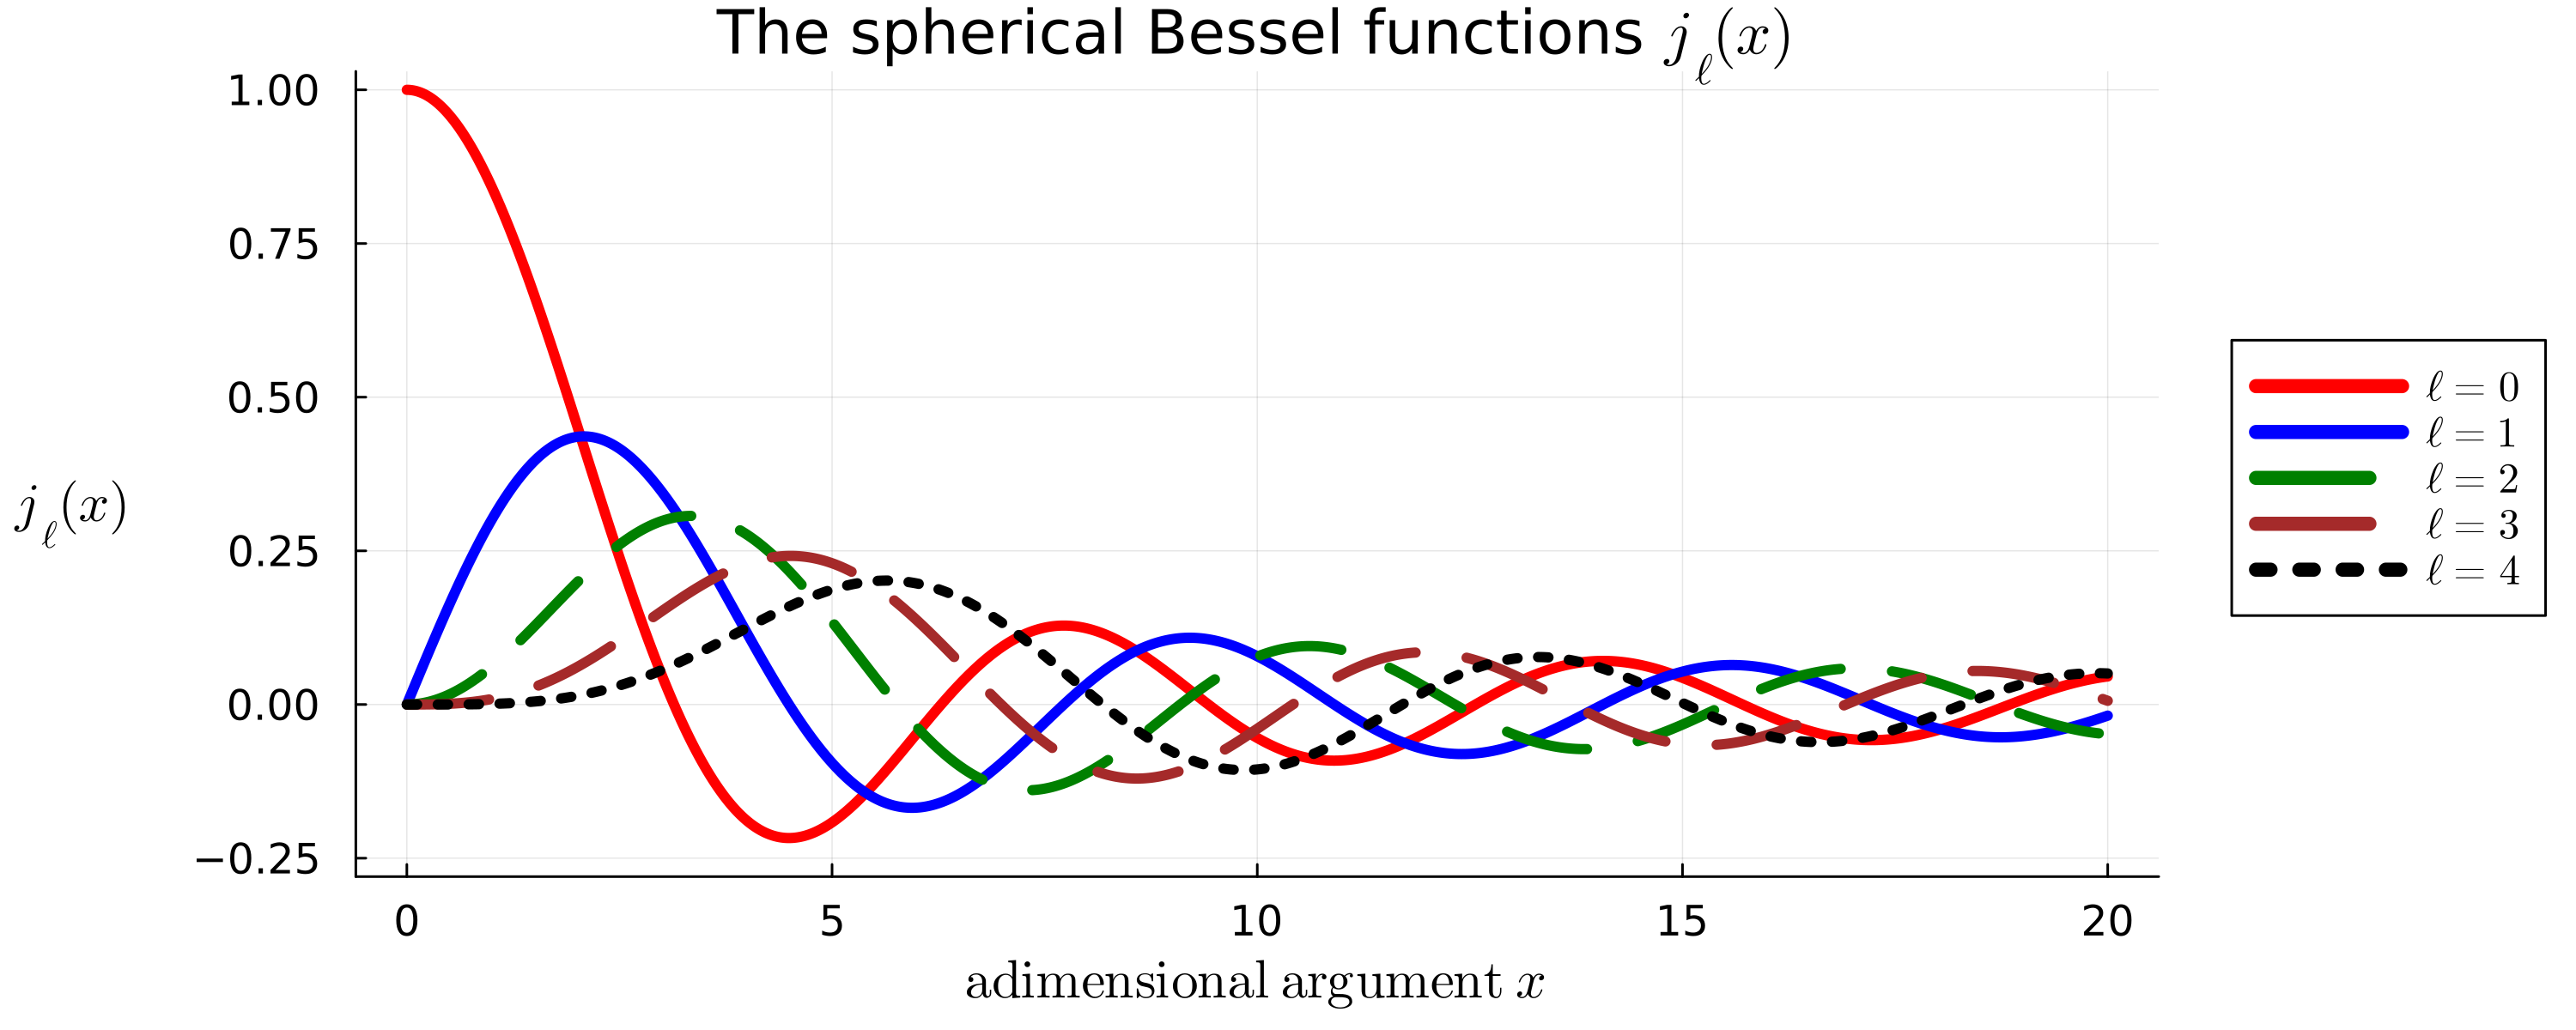

In [22]:
plot_bessels(ylims=(-0.28, 1.03), yticks=[x for x in -0.25:0.25:1])

## Where the small-$x$ expansion holds

$|j_\ell(x)|$ against its leading term $x^\ell/(2\ell+1)!!$. The two coincide only below
the first zero, which is what sets the validity range of every small-$s$ limit built on
this expansion.

The lower panel is their ratio, on a scale narrow enough to read it: on the log-log plot
above the two curves of each $\ell$ look superimposed over a dozen decades, which is
exactly the impression to resist. The truncation is good to 10% up to $x = 0.79$ for
$\ell = 0$, and the bound drifts only slowly with the order ($1.02$, $1.21$, $1.37$,
$1.52$ for $\ell = 1 \ldots 4$), so $x \simeq 1$ is the right single number to
remember.

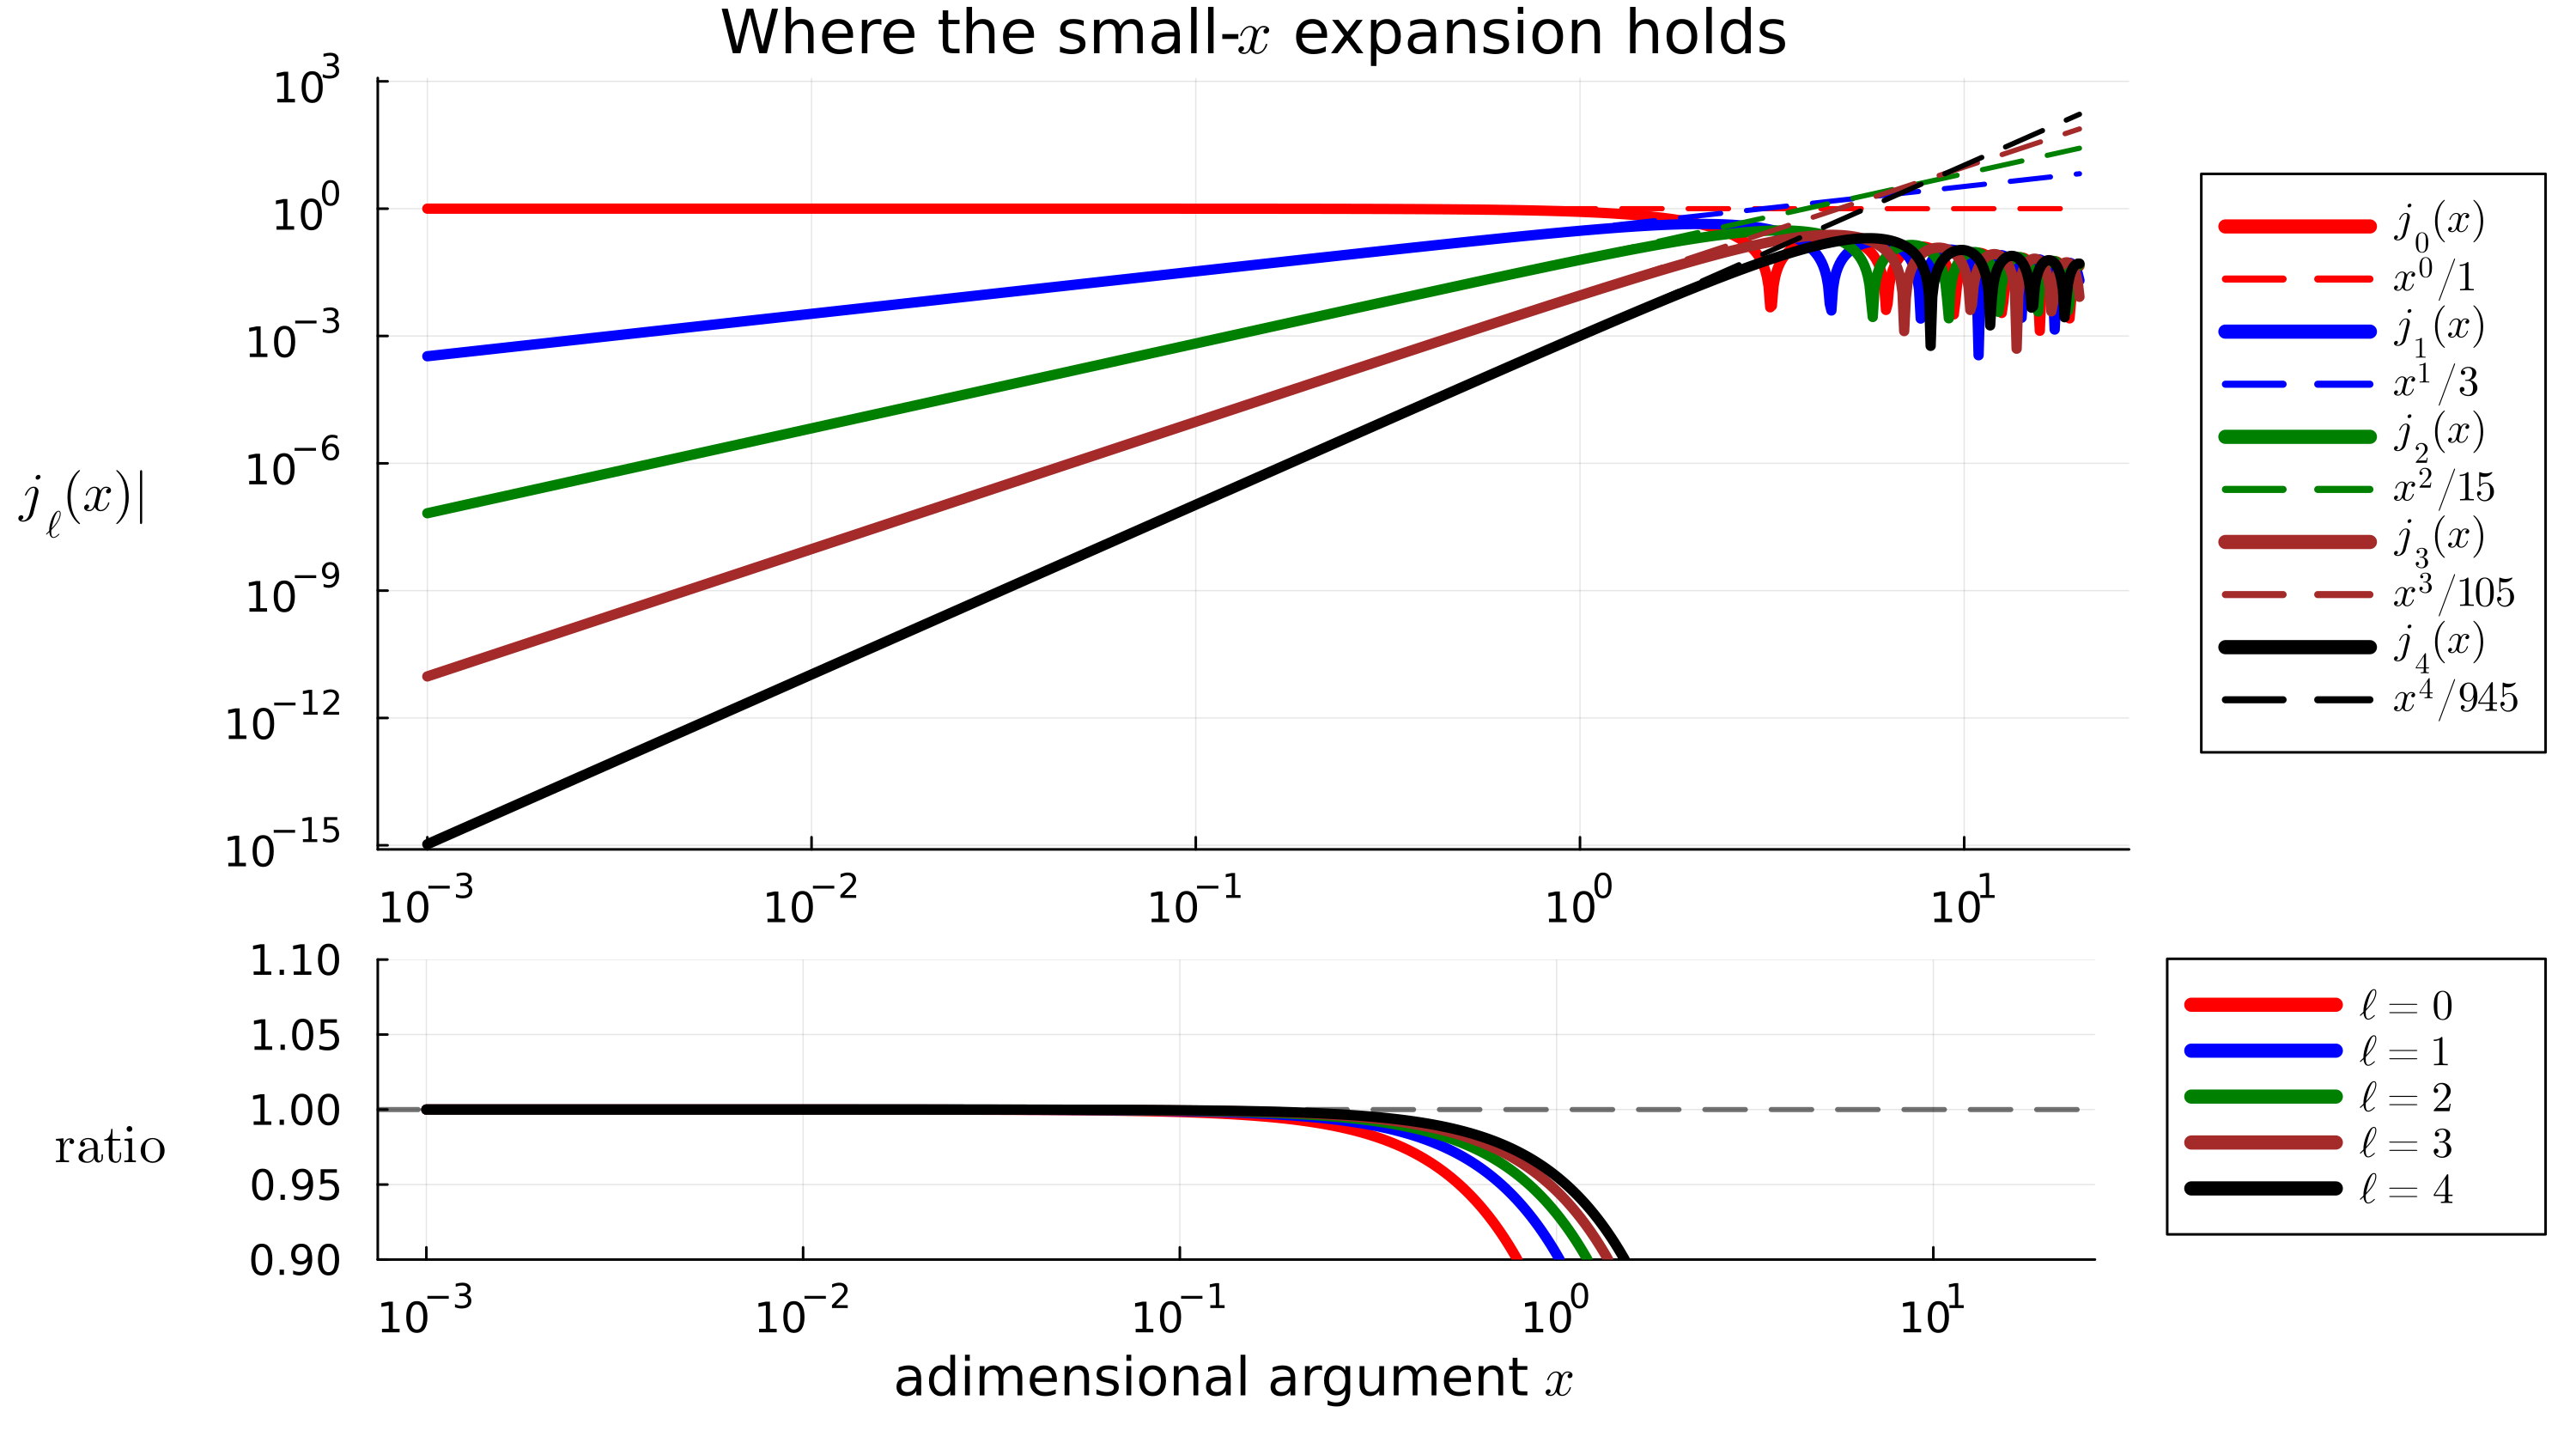

In [23]:
plot_small_x_with_ratio()

## The first zero of $j_\ell$

Computed by bisection for $\ell = 0 \ldots$ `L_MAX`, then compared with a linear fit and
with the asymptotic $\ell + 1.8557 \, \ell^{1/3}$.

The lower panel is each approximation divided by the numerical value. On the linear scale
above the three curves are indistinguishable. The straight line is off by 51% at
$\ell = 0$ and enters the 10% band at $\ell = 4$; the asymptotic form vanishes at
$\ell = 0$ and enters at $\ell = 7$. Past that they part company: the fit is within 1%
from $\ell = 12$, the asymptotic form only from $\ell = 69$.

In [24]:
zeros_l = [first_zero(l) for l in 0:L_MAX]
q, m = linear_fit(collect(0:L_MAX), zeros_l)
@printf("linear regression: x = %.4f + %.4f l\n", q, m)

linear regression: x = 4.7466 + 1.0513 l


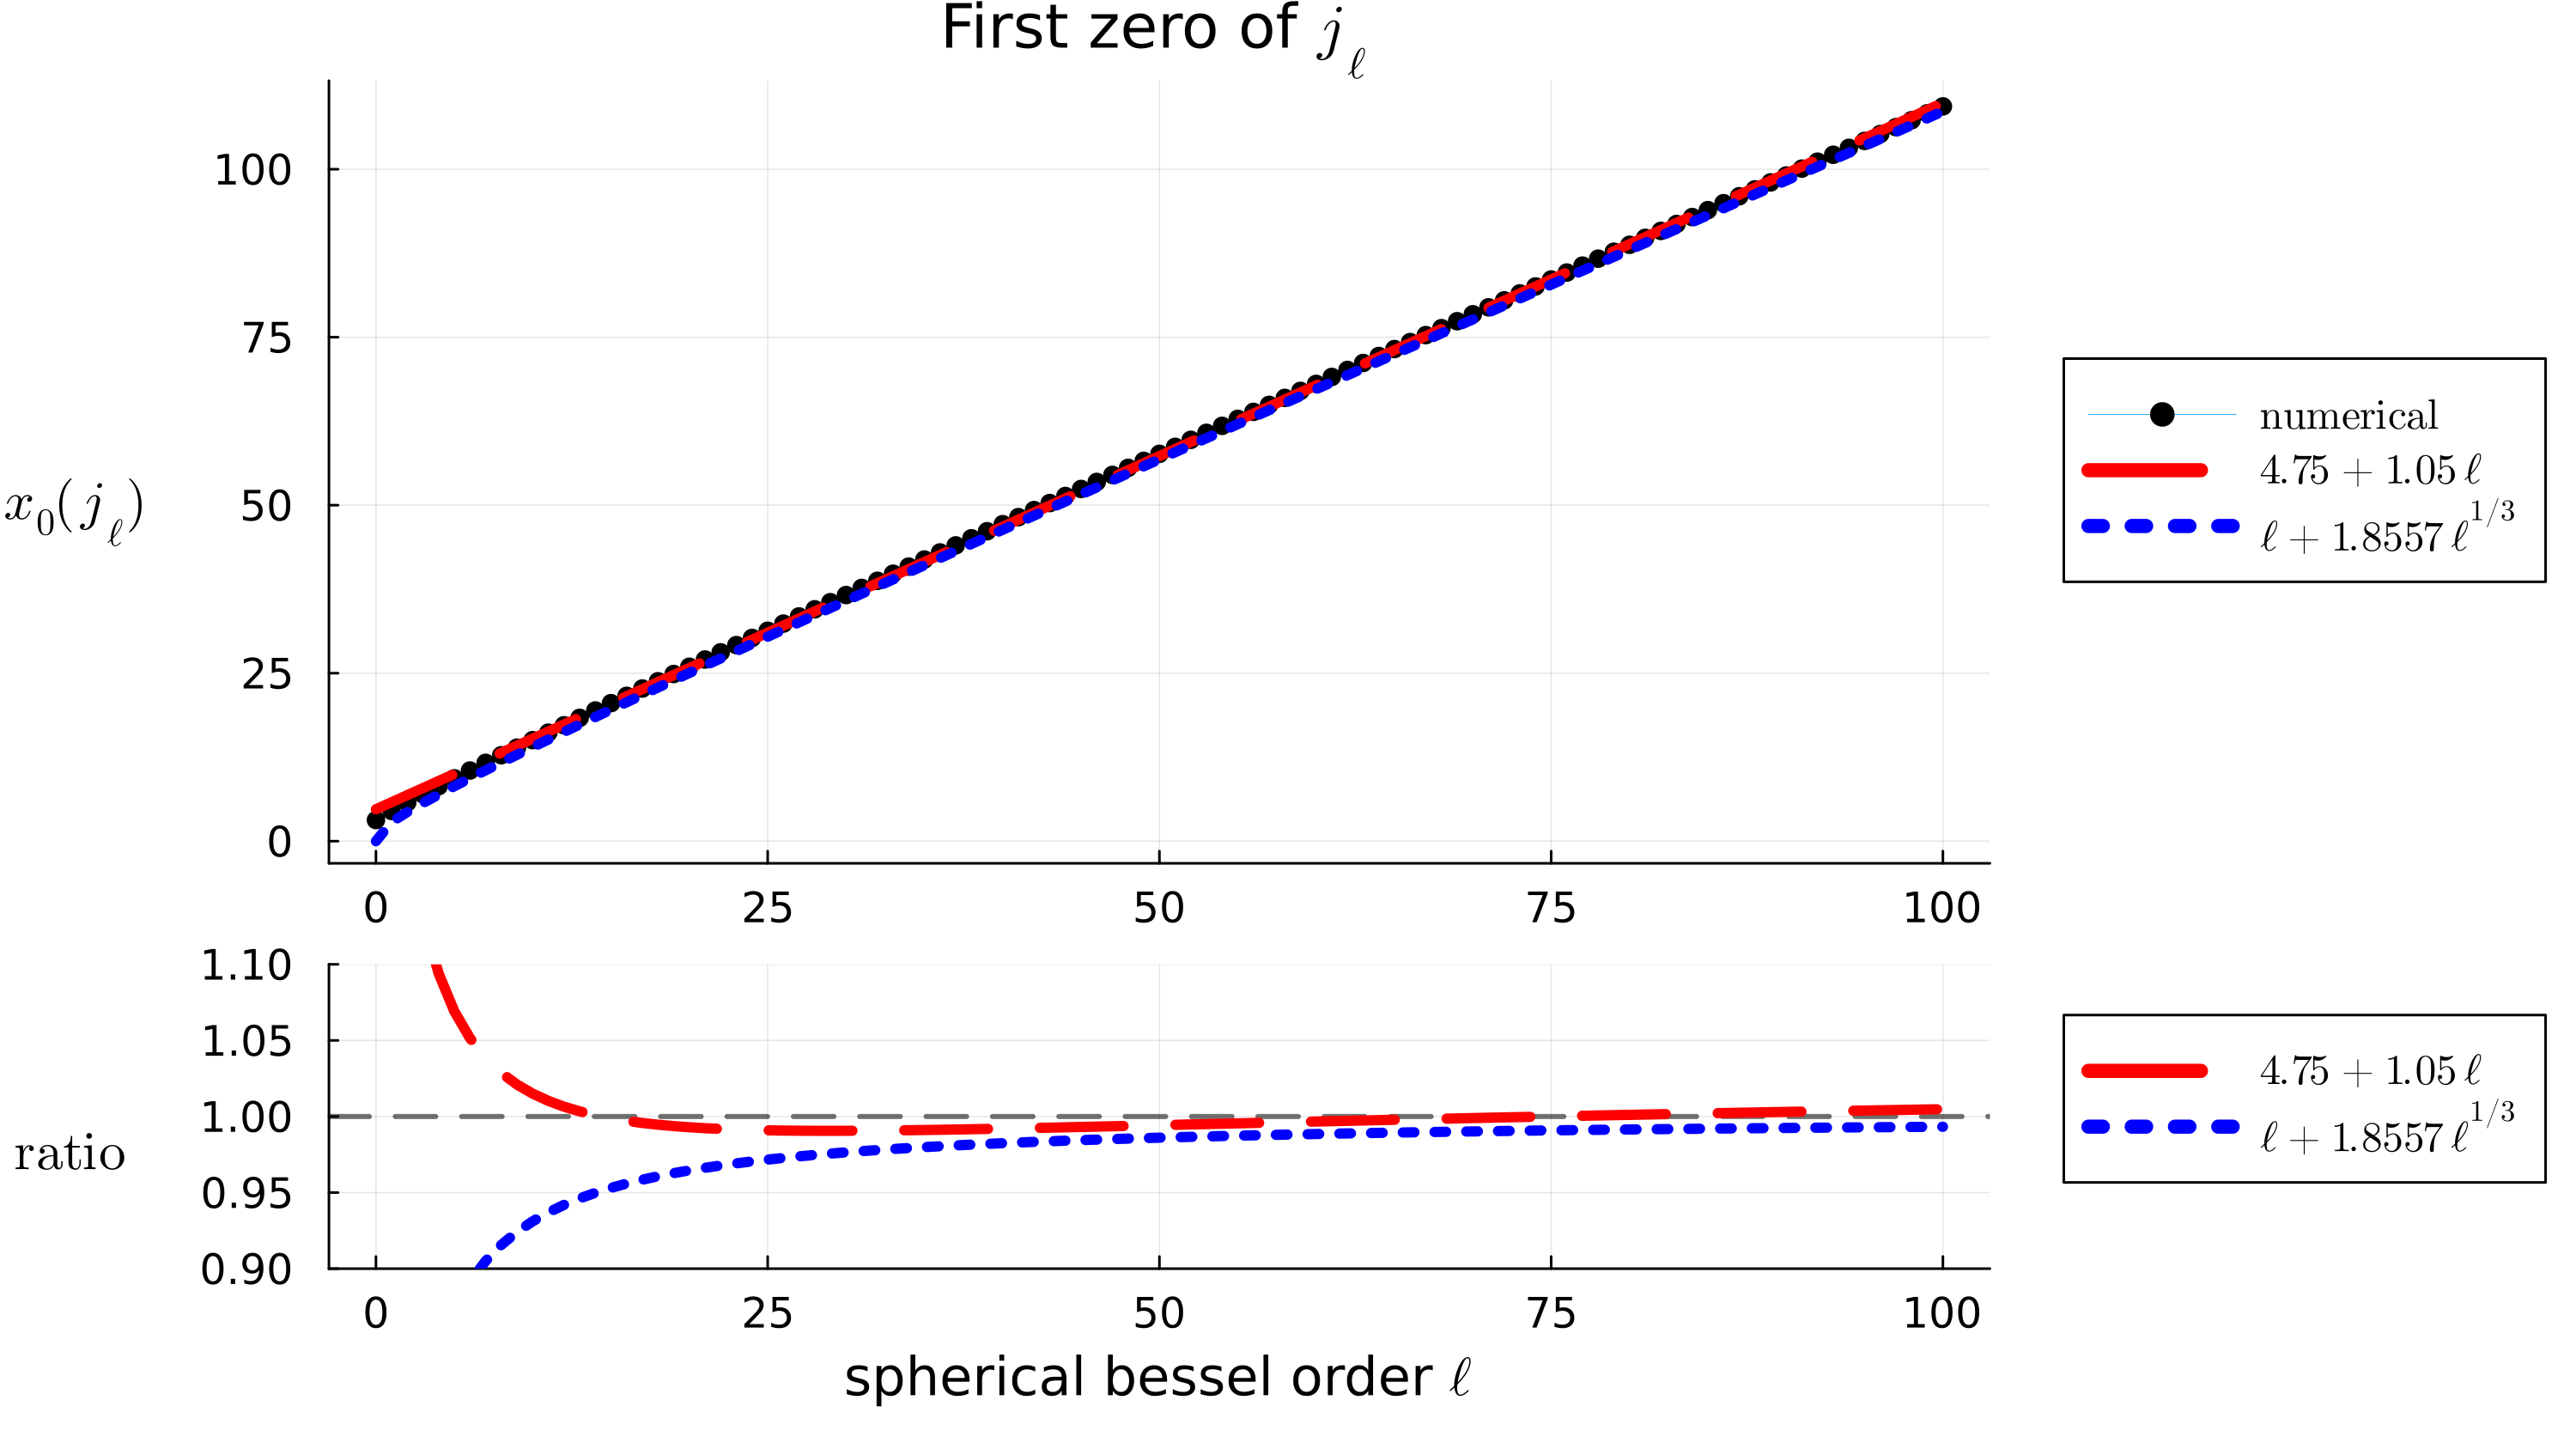

In [25]:
plot_first_zeros_with_ratio(zeros_l)

## Save the plots and the data

In [26]:
save_plot(plot_bessels(ylims=(-0.28, 1.03), yticks=[x for x in -0.25:0.25:1]), "spherical_bessels.png")
save_plot(plot_small_x_with_ratio(), "spherical_bessels_smallx.png")
save_plot(plot_first_zeros_with_ratio(zeros_l), "spherical_bessels_firstzeros.png")
save_data(zeros_l)

"/Users/di75tom/AAA_TESI_MAGISTRALE/GaPSE_CODING/GaPSE-worktree/myspline/theory/spherical_bessels/first_zeros.txt"

## END